In [1]:
!pip install opencv-python numpy pandas tqdm matplotlib scikit-learn joblib

In [2]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils import resample

import joblib


In [3]:
# função que extrai média a* e b* de uma imagem
def extract_mean_lab(image_path: str):
    img = cv2.imread(str(image_path))
    if img is None:
        raise ValueError(f"Imagem não encontrada: {image_path}")
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    # a* está no canal 1, b* no canal 2
    a_mean = float(lab[:, :, 1].mean())
    b_mean = float(lab[:, :, 2].mean())
    return a_mean, b_mean


In [4]:
# carregar todas as imagens de teste/green|red|blue e extrair a*,b*
def load_ab_from_folders(base_folder="teste", verbose=True):
    base_path = Path(base_folder)
    if not base_path.exists():
        raise FileNotFoundError(f"Pasta '{base_folder}' não encontrada")
    
    label_map = {"green": 0, "red": 1, "blue": 2}
    records = []
    
    for color in label_map.keys():
        color_path = base_path / color
        if not color_path.exists():
            if verbose:
                print(f"[AVISO] pasta ausente: {color_path}")
            continue
        images = list(color_path.glob("*"))
        for img_path in tqdm(images, desc=f"Carregando {color}", unit="img"):
            a, b = extract_mean_lab(img_path)
            records.append({"image": img_path.name, "a": a, "b": b, "Color": color, "label": label_map[color]})
    
    df = pd.DataFrame(records)
    if verbose:
        print("Total samples:", len(df))
        print(df['Color'].value_counts())
    return df


In [5]:
# balanceamento por classe: method='undersample' ou 'oversample'
def balance_dataframe(df: pd.DataFrame, method="undersample", random_state=42):
    """
    Retorna um novo DataFrame balanceado.
    method: 'undersample' (reduce to minority) or 'oversample' (increase to majority)
    """
    groups = [g for _, g in df.groupby("label")]
    counts = [len(g) for g in groups]
    if len(counts) == 0:
        return df
    if method == "undersample":
        min_count = min(counts)
        balanced = []
        for _, g in df.groupby("label"):
            if len(g) > min_count:
                g_res = resample(g, replace=False, n_samples=min_count, random_state=random_state)
            else:
                g_res = g
            balanced.append(g_res)
        df_bal = pd.concat(balanced).sample(frac=1, random_state=random_state).reset_index(drop=True)
        return df_bal
    elif method == "oversample":
        max_count = max(counts)
        balanced = []
        for _, g in df.groupby("label"):
            if len(g) < max_count:
                g_res = resample(g, replace=True, n_samples=max_count, random_state=random_state)
            else:
                g_res = g
            balanced.append(g_res)
        df_bal = pd.concat(balanced).sample(frac=1, random_state=random_state).reset_index(drop=True)
        return df_bal
    else:
        raise ValueError("method deve ser 'undersample' ou 'oversample'")


In [6]:
# pipeline de preparação: carregar, balancear, split (train/val/test)
def prepare_dataset(base_folder="teste", balance_method="undersample", test_size=0.2, val_size=0.1, random_state=42):
    # 1) carregar
    df = load_ab_from_folders(base_folder, verbose=True)
    if df.empty:
        raise RuntimeError("Dataset vazio após carga.")
    
    # 2) balancear
    df_bal = balance_dataframe(df, method=balance_method, random_state=random_state)
    print("Distribuição após balanceamento:")
    print(df_bal['Color'].value_counts())
    
    # 3) features e labels
    X = df_bal[['a', 'b']].values.astype(np.float32)
    y = df_bal['label'].values.astype(int)
    
    # 4) split train / temp
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=(test_size + val_size), stratify=y, random_state=random_state
    )
    # 5) split temp -> val / test (proporcional)
    val_relative = val_size / (test_size + val_size)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=1 - val_relative, stratify=y_temp, random_state=random_state
    )
    
    print("Tamanhos: train=%d | val=%d | test=%d" % (len(X_train), len(X_val), len(X_test)))
    
    # 6) Construir DataFrames informativos (opcional)
    df_train = pd.DataFrame(X_train, columns=['a','b'])
    df_train['label'] = y_train
    df_val = pd.DataFrame(X_val, columns=['a','b'])
    df_val['label'] = y_val
    df_test = pd.DataFrame(X_test, columns=['a','b'])
    df_test['label'] = y_test
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), df_bal


In [7]:
# treinando MLP simples
def train_mlp(X_train, y_train, hidden_layers=(16,16), max_iter=1000, random_state=42):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPClassifier(hidden_layer_sizes=hidden_layers,
                              activation='relu',
                              solver='adam',
                              max_iter=max_iter,
                              random_state=random_state))
    ])
    pipe.fit(X_train, y_train)
    return pipe

In [8]:
# avaliação: relatório + matriz de confusão normalizada + acurácia
def evaluate_model(model, X, y, target_names=["green","red","blue"], show_confusion=True):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print("Accuracy: %.4f" % acc)
    print(classification_report(y, y_pred, target_names=target_names))
    
    if show_confusion:
        cm = confusion_matrix(y, y_pred)
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        fig, ax = plt.subplots(1,2, figsize=(12,4))
        ax[0].imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax[0].set_title("Confusion matrix (counts)")
        ax[1].imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
        ax[1].set_title("Confusion matrix (normalized)")
        for i in range(2):
            ax[i].set_xticks([0,1,2]); ax[i].set_yticks([0,1,2])
            ax[i].set_xlabel("Predicted"); ax[i].set_ylabel("True")
        plt.show()
    return y_pred


In [9]:
# plotar fronteira de decisão + pontos de teste
def plot_decision_boundary(model, X, y, title="Decision boundary (a*b*)", grid_step=1.0):
    # Assumimos scaler dentro do pipeline
    scaler = model.named_steps['scaler']
    classifier = model.named_steps['mlp']
    
    # criar grid no espaço das features (a,b)
    a_min, a_max = X[:,0].min() - 10, X[:,0].max() + 10
    b_min, b_max = X[:,1].min() - 10, X[:,1].max() + 10
    aa, bb = np.meshgrid(np.arange(a_min, a_max, grid_step), np.arange(b_min, b_max, grid_step))
    grid = np.c_[aa.ravel(), bb.ravel()]
    # padroniza grid e prediz
    grid_scaled = scaler.transform(grid)
    zz = classifier.predict(grid_scaled)
    zz = zz.reshape(aa.shape)
    
    plt.figure(figsize=(8,6))
    plt.contourf(aa, bb, zz, alpha=0.2, levels=[-0.5,0.5,1.5,2.5], cmap=plt.cm.Paired)
    # scatter pontos
    label_colors = {0:"green", 1:"red", 2:"blue"}
    for lbl in np.unique(y):
        pts = X[y==lbl]
        plt.scatter(pts[:,0], pts[:,1], c=label_colors[lbl], label=["green","red","blue"][lbl], edgecolor='k', s=40, alpha=0.8)
    plt.xlabel("a*")
    plt.ylabel("b*")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


Carregando green:   0%|          | 0/4604 [00:00<?, ?img/s]

Carregando red:   0%|          | 0/9200 [00:00<?, ?img/s]

Carregando blue:   0%|          | 0/3450 [00:00<?, ?img/s]

Total samples: 17254
Color
red      9200
green    4604
blue     3450
Name: count, dtype: int64
Distribuição após balanceamento:
Color
blue     3450
green    3450
red      3450
Name: count, dtype: int64
Tamanhos: train=7244 | val=1035 | test=2071
== VAL SET ==
Accuracy: 1.0000
              precision    recall  f1-score   support

       green       1.00      1.00      1.00       345
         red       1.00      1.00      1.00       345
        blue       1.00      1.00      1.00       345

    accuracy                           1.00      1035
   macro avg       1.00      1.00      1.00      1035
weighted avg       1.00      1.00      1.00      1035



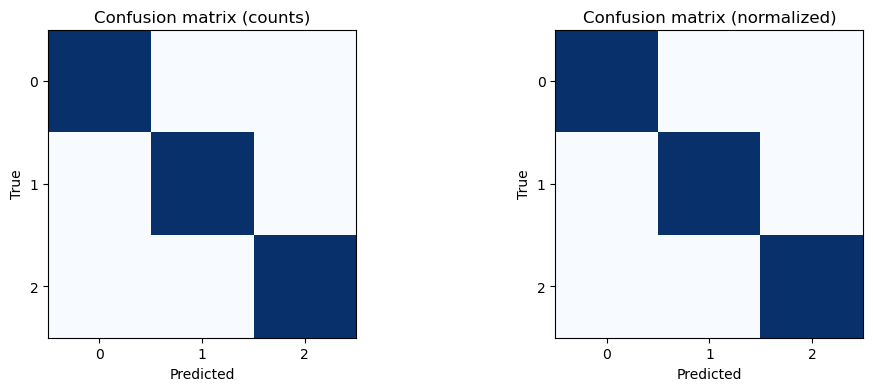

== TEST SET ==
Accuracy: 1.0000
              precision    recall  f1-score   support

       green       1.00      1.00      1.00       690
         red       1.00      1.00      1.00       690
        blue       1.00      1.00      1.00       691

    accuracy                           1.00      2071
   macro avg       1.00      1.00      1.00      2071
weighted avg       1.00      1.00      1.00      2071



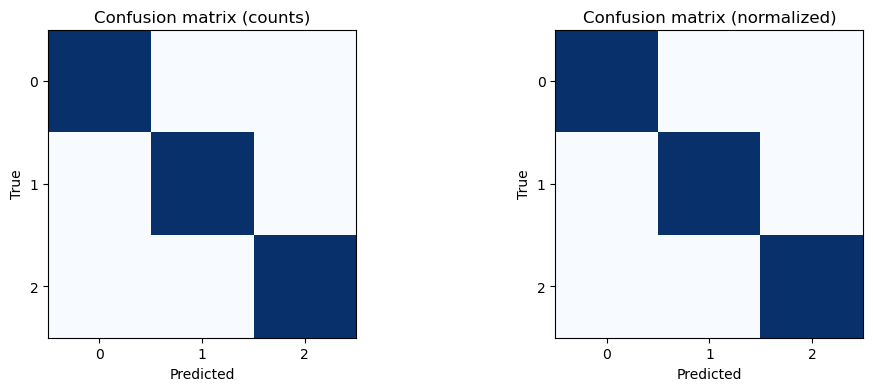

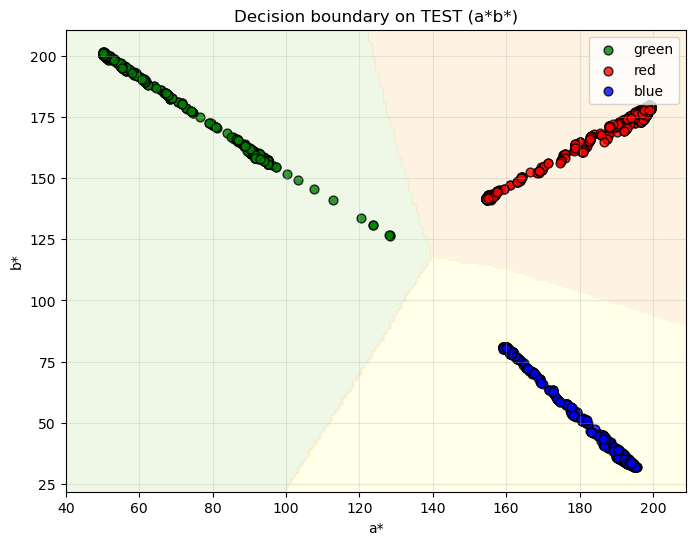

Modelo salvo em mlp_ab_model.joblib


In [10]:
# execução completa
# 1) preparar dataset (balanceado por undersample)
(X_train, y_train), (X_val, y_val), (X_test, y_test), df_bal = prepare_dataset(
    base_folder="teste",
    balance_method="undersample",  # ou "oversample"
    test_size=0.2,
    val_size=0.1,
    random_state=42
)

# 2) treinar
model = train_mlp(X_train, y_train, hidden_layers=(16,16), max_iter=2000, random_state=42)

# 3) avaliar em val (checagem rápida)
print("== VAL SET ==")
evaluate_model(model, X_val, y_val)

# 4) avaliar em test (resultado final)
print("== TEST SET ==")
evaluate_model(model, X_test, y_test)

# 5) plotar fronteira e pontos de teste
plot_decision_boundary(model, X_test, y_test, title="Decision boundary on TEST (a*b*)")

# 6) salvar modelo (opcional)
joblib.dump(model, "mlp_ab_model.joblib")
print("Modelo salvo em mlp_ab_model.joblib")
